In [1]:
import numpy as np

from starccato_flow.supernovae.supernovae import Supernovae
from starccato_flow.plotting.sky import plot_galactic_supernovae_polar_hemispheres

MPS device found


✓ Loaded 1934076 supernova locations from /Users/tarineccleston/Desktop/starccato/starccato-flow/../data/supernovae/exploded_supernovae_t100_sf5.csv
914

Galactic Center Direction:
  RA:  4.649646 rad = 266.41°
  Dec: -0.505032 rad = -28.94°



/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')
/Users/tarineccleston/Desktop/starccato/starccato-flow/.venv/lib/python3.9/site-packages/matplotlib/backends/backend_pdf.py:1758: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(rgb8, mode='P')


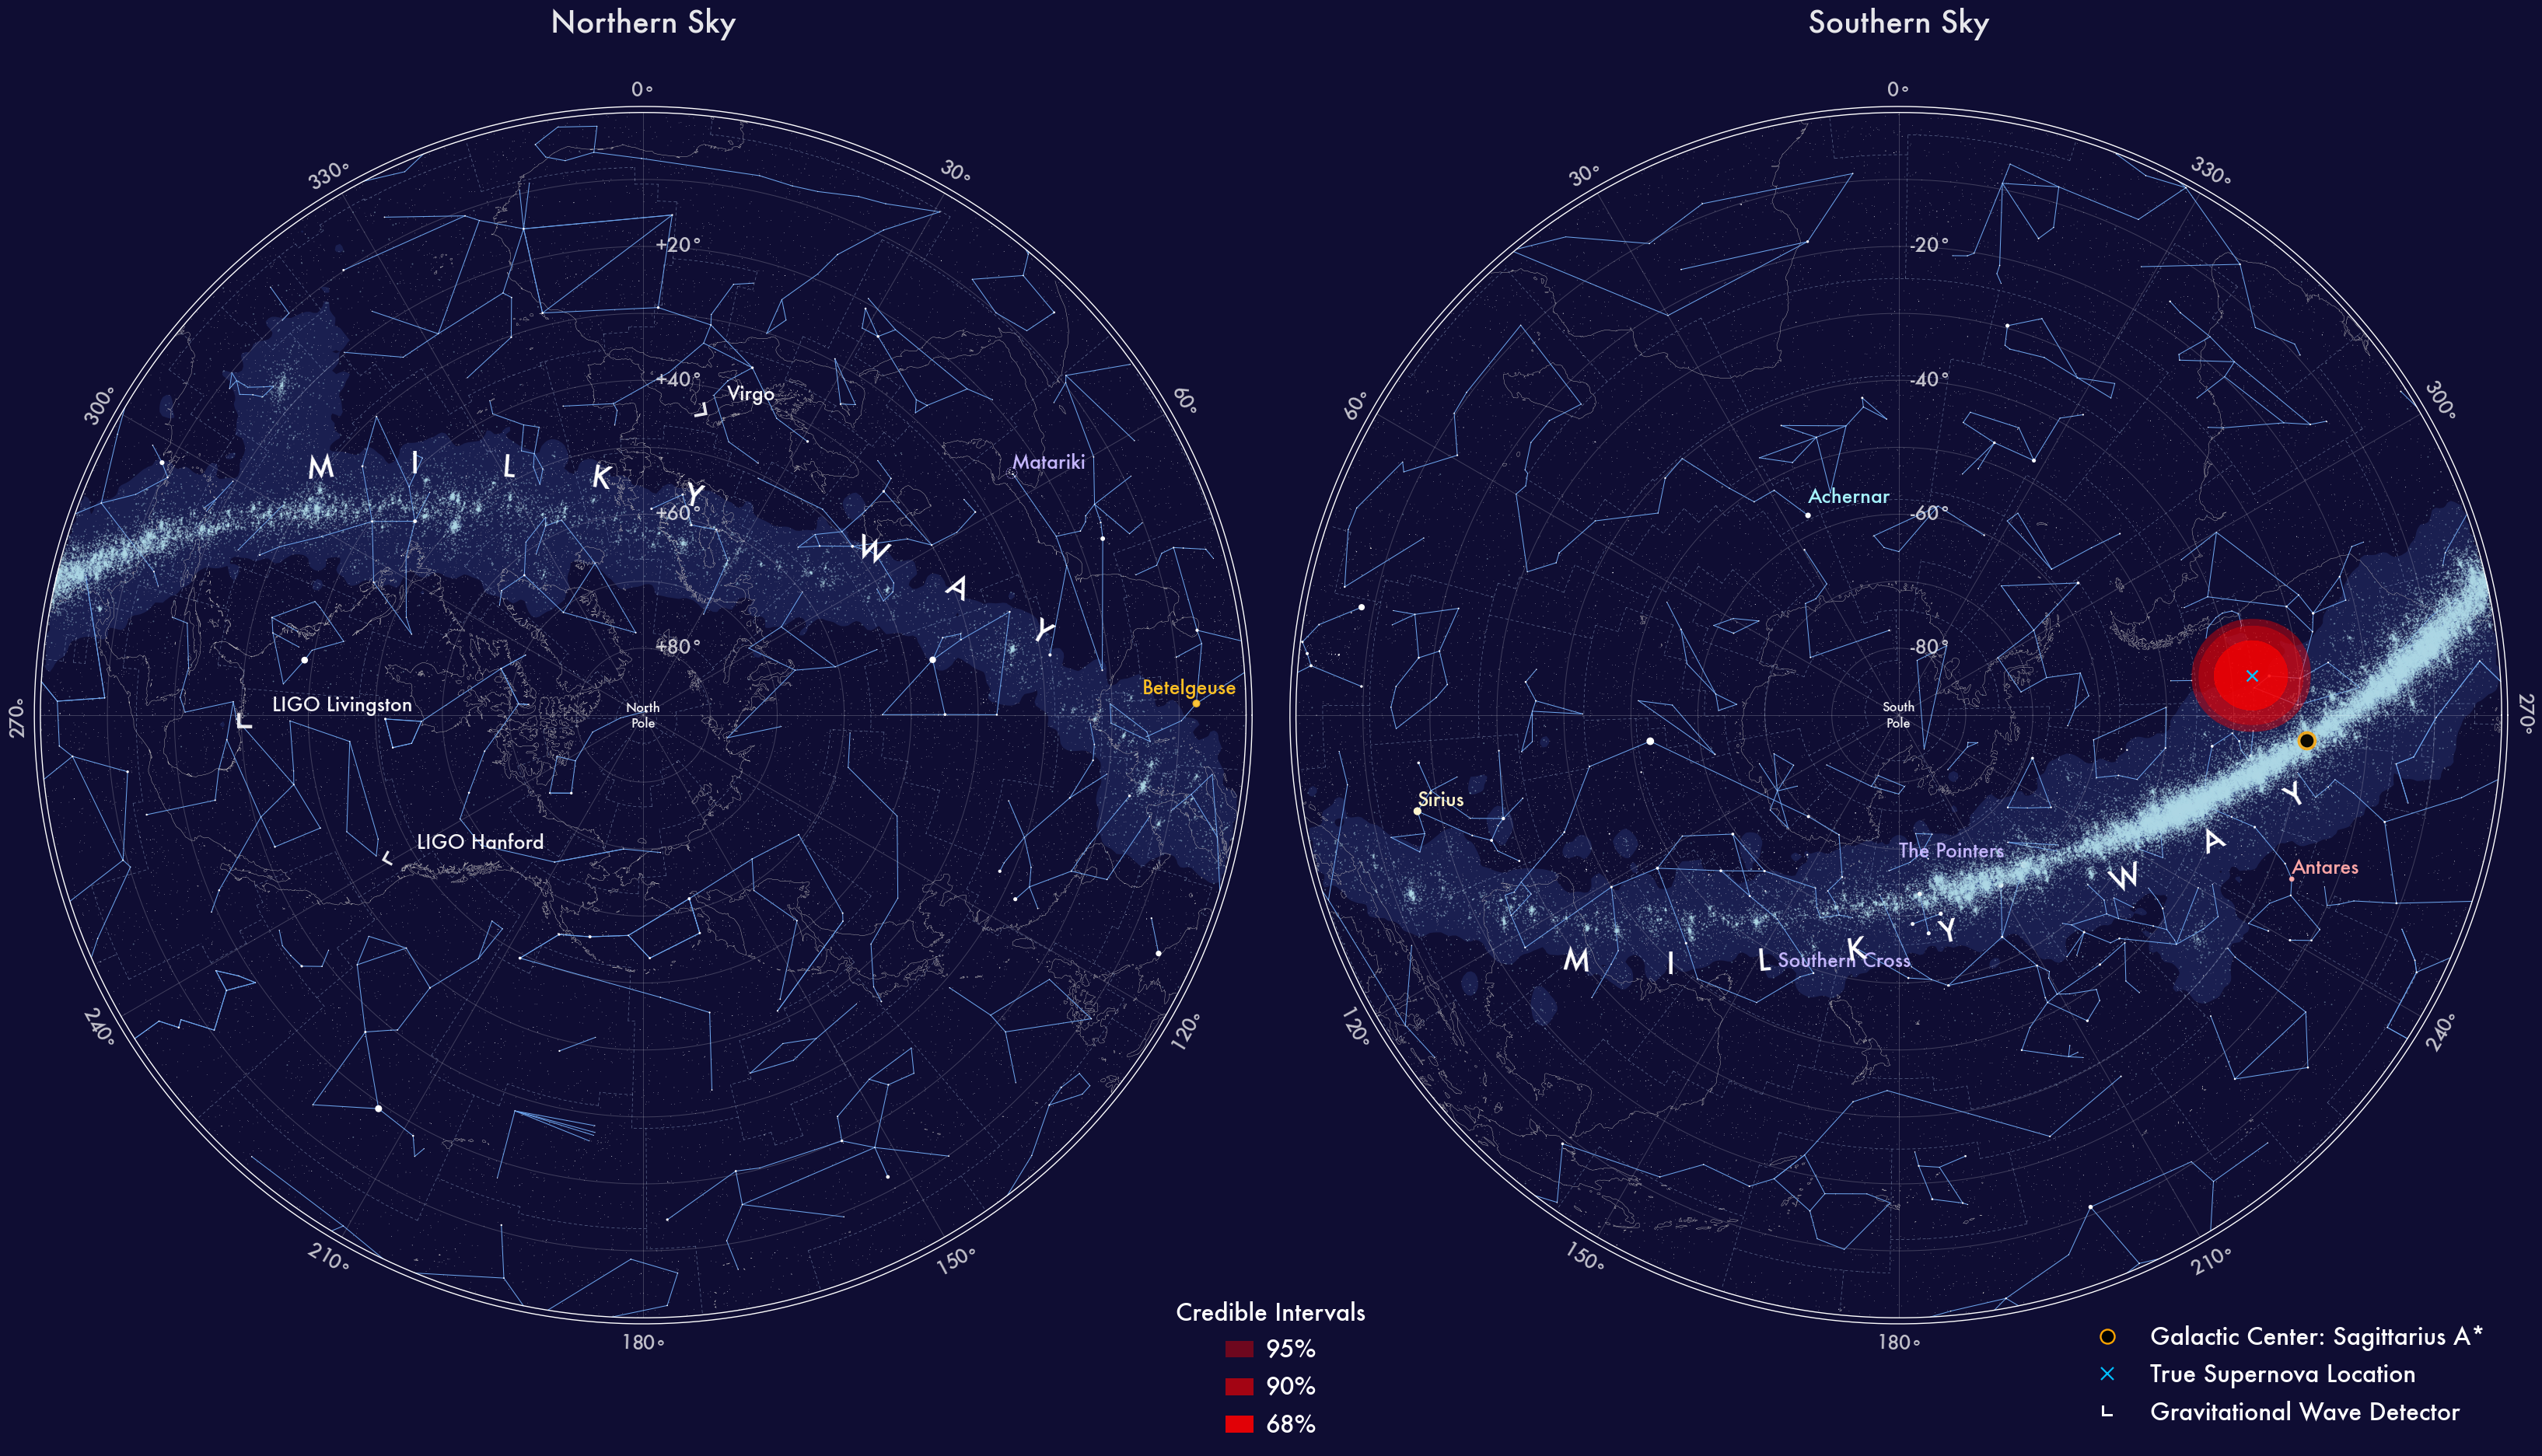

In [ ]:
ccsn = Supernovae(complex=True)

# Use a location close to the galactic center but offset by ~10 degrees
gc_ra, gc_dec = ccsn.get_galactic_center_direction()
true_ra = gc_ra + np.deg2rad(10.0)  # Offset ~10 degrees in RA
true_dec = gc_dec - np.deg2rad(8.0)  # Offset ~8 degrees in Dec

# Generate example posterior samples around this location
np.random.seed(42)
n_posterior_samples = 3000

# Create a slightly spread-out posterior around the location
ra_posterior = np.random.normal(true_ra, 0.05, n_posterior_samples)
dec_posterior = np.random.normal(true_dec, 0.05, n_posterior_samples)

plot_galactic_supernovae_polar_hemispheres(
    ccsn,
    posterior_ra_samples=ra_posterior,
    posterior_dec_samples=dec_posterior,
    true_ra_override=true_ra,
    true_dec_override=true_dec,
    show_constellation_borders=True,
    fname="supernovae_galactic_polar_hemispheres.pdf",
    font_family="sans-serif",
    font_name="Futura",
    n_background_supernovae=100000,
    background="black",
    coastline=True,
)